In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#sns.set_theme(style="white")

num_humans = 50
mos_x_human = 5

igd_values = [10, 30, 50, 75, 90]
all_biting_rates = [0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0, 2.5, 3.0]

results_dir = "./results"


def apply_conversions(df: pd.DataFrame, num_hum: int, num_mos: int) -> pd.DataFrame:
    df = df.copy()

    for col in ["HS", "HM", "HPC"]:
        if col in df.columns:
            df[col] = 100.0 * df[col] / num_hum

    for col in ["MS", "MC", "MPC"]:
        if col in df.columns:
            df[col] = 100.0 * df[col] / num_mos

    if "PI_Humans" in df.columns:
        df["PI_Humans"] *= 100.0

    if "PI_Mosquitoes" in df.columns:
        df["PI_Mosquitoes"] *= 100.0

    return df

def scenario_folder(igd, br, num_humans, mos_x_human):
    return os.path.join(results_dir,f"IGD_{igd}_BR_{br}_NH_{num_humans}_MxH_{mos_x_human}")

def list_replica_files(igd, br, num_humans, mos_x_human):
    folder = scenario_folder(igd, br, num_humans, mos_x_human)
    pattern = os.path.join(folder, "Iteration_proof_*.txt")
    return sorted(glob.glob(pattern))

def load_final_values(metric, igd, br, num_humans, mos_x_human):
    files = list_replica_files(igd, br, num_humans, mos_x_human)
    num_mos = num_humans * mos_x_human
    values = []

    for f in files:
        df = pd.read_csv(f, sep=";")
        df = apply_conversions(df, num_humans, num_mos)

        if "time" in df.columns:
            df = df.sort_values("time")

        if metric not in df.columns:
            continue

        values.append(float(df.iloc[-1][metric]))

    return [v for v in values if np.isfinite(v)]

In [2]:
plt.rcParams.update({"font.size": 6,
                     "axes.labelsize": 8,
                     "xtick.labelsize": 7,
                     "ytick.labelsize": 7,
                     "legend.fontsize": 6,
                     "legend.title_fontsize": 7})

figsize_heatmap = (9/2.54,4/2.54)
figsize_big = (9/2.54,8/2.54)

In [3]:
## MOI Heatmap ##
moi_heatmap = np.full((len(igd_values), len(all_biting_rates)), np.nan)

for i, igd in enumerate(reversed(igd_values)):
    for j, br in enumerate(all_biting_rates):
        vals = load_final_values("MOI_Humans_median", igd, br, num_humans, mos_x_human)
        if vals:
            moi_heatmap[i, j] = np.median(vals)

### MOI - Median

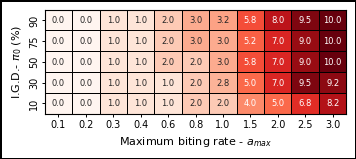

In [4]:
fig, ax = plt.subplots(figsize=figsize_heatmap)

sns.heatmap(moi_heatmap,ax=ax,cmap="Reds", annot=True, 
            fmt=".1f", linewidths=0.5, linecolor="black",
            yticklabels=[str(x) for x in reversed(igd_values)],
            xticklabels=[str(x) for x in all_biting_rates],
            cbar=False)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(.8)
    spine.set_color("black")
    
ax.set_ylabel(f"I.G.D.- $\pi_0$ (%)")
ax.set_xlabel(r"Maximum biting rate - $a_{max}$")
ax.tick_params(axis='both', which='major', direction='out', length=2, width=0.7, pad=2)
plt.tight_layout()
plt.savefig("./Figures/Fig_1_moi_heatmap_median.png", dpi=600, bbox_inches="tight")

fig.patch.set_facecolor("white")
fig.patch.set_edgecolor("black")
fig.patch.set_linewidth(1)
plt.show()

### Number of Haplotypes

In [5]:
## Number of Haplotypes ##
num_hap_heatmap = np.full((len(igd_values), len(all_biting_rates)), np.nan)

for i, igd in enumerate(reversed(igd_values)):
    for j, br in enumerate(all_biting_rates):
        vals = load_final_values("num_haplotypes", igd, br, num_humans, mos_x_human)
        if vals:
            num_hap_heatmap[i, j] = np.median(vals)

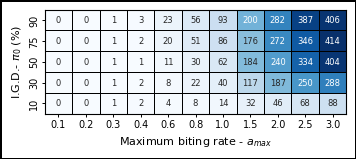

In [6]:
fig, ax = plt.subplots(figsize=figsize_heatmap)

sns.heatmap(num_hap_heatmap,ax=ax,cmap="Blues", annot=True, 
            fmt=".0f", linewidths=0.5, linecolor="black",
            yticklabels=[str(x) for x in reversed(igd_values)],
            xticklabels=[str(x) for x in all_biting_rates],
            cbar=False)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(.8)
    spine.set_color("black")
    
ax.set_ylabel(f"I.G.D.- $\pi_0$ (%)")
ax.set_xlabel(r"Maximum biting rate - $a_{max}$")
ax.tick_params(axis='both', which='major', direction='out', length=2, width=0.7, pad=2)
plt.tight_layout()
plt.savefig("./Figures/Fig_1_num_hap_heatmap_median.png", dpi=600, bbox_inches="tight")

fig.patch.set_facecolor("white")
fig.patch.set_edgecolor("black")
fig.patch.set_linewidth(1)
plt.show()

### Recombination Ratio

In [7]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def gaussian_kde_manual(samples: np.ndarray, grid: np.ndarray,
                        bw: float = None, lower: int = 0, upper: int = 1) -> np.ndarray:
    samples = np.asarray(samples, dtype=float)
    samples = samples[np.isfinite(samples)]

    if len(samples) == 0:
        return np.zeros_like(grid)

    if len(samples) == 1:
        bw = 0.01 if bw is None else bw
    else:
        std = np.std(samples, ddof=1)
        if bw is None:
            bw = max(1.06 * std * len(samples) ** (-1 / 5), 0.005)
        else:
            bw = max(float(bw), 0.003)

    diffs = (grid[:, None] - samples[None, :]) / bw
    density = np.exp(-0.5 * diffs ** 2).sum(axis=1)
    density /= (len(samples) * bw * np.sqrt(2 * np.pi))
    density[(grid < lower) | (grid > upper)] = 0.0

    return density

In [8]:
ratio_rows = []
selected_biting_rates = [0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0, 2.5, 3.0]

for br in selected_biting_rates:
    for igd in igd_values:
        vals = load_final_values("ratio_reco", igd, br, num_humans, mos_x_human)
        for v in vals:
            ratio_rows.append({"BR": br,"IGD": igd,"value": v})

ratio_df = pd.DataFrame(ratio_rows)

if ratio_df.empty:
    raise ValueError("No data found for ratio_reco.")

ratio_df.head()

,BR,IGD,value
0,0.1,10,0.0
1,0.1,10,0.0
2,0.1,10,0.0
3,0.1,10,0.0
4,0.1,10,0.0


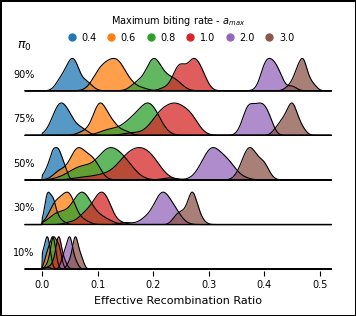

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

selected_biting_rates = [0.4, 0.6, 0.8, 1.0,2.0,3.0]

#selected_biting_rates = [0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0, 2.5, 3.0]

# 1) Build a common x-grid for all KDEs (shared x-axis scale) #
xmin = max(-0.05, ratio_df["value"].min() -  0.03)
xmax = min(1, ratio_df["value"].max() + 0.03)
xgrid = np.linspace(xmin, xmax, 500)

# 2) Assign BR colors using Matplotlib's tab10 colormap #
tab10 = plt.get_cmap("tab10")
br_list = list(selected_biting_rates)  # ensure stable ordering
br_colors = {br: tab10(i % 10) for i, br in enumerate(br_list)}

# 3) Create subplots: each row corresponds to an IGD value #
fig, axes = plt.subplots(nrows=len(igd_values),
                         ncols=1,
                         figsize=figsize_big,
                         sharex=True)

# If only one row, wrap axes so the loop works the same way #
if len(igd_values) == 1:
    axes = [axes]

# 4) Main loop: One axis (row) per IGD - Within each row, plot one KDE curve per BR
for ax, igd in zip(axes, reversed(igd_values)):

    # Plot curves for each biting rate within this IGD row #
    for br in br_list:
        # Select values for this (IGD, BR) combination
        vals = ratio_df[(ratio_df["BR"] == br) & (ratio_df["IGD"] == igd)]["value"].values
        if len(vals) == 0:
            continue

        # Compute KDE on the shared grid #
        dens = gaussian_kde_manual(vals, xgrid,upper = 1)
        

        # Normalize so curves have comparable height #
        if dens.max() > 0:
            dens = dens / dens.max() * 0.9

        # Filled density + outline #
        ax.fill_between(xgrid, 0, dens,
                        color=br_colors[br],alpha=0.75,linewidth=0)
        ax.plot(xgrid, dens, color="black", linewidth=0.8)

    # Baseline and styling #
    #ax.axhline(0, color="black", linewidth=0.7)
    ax.set_yticks([])

    # Remove spines for a clean look #
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    # Row label: IGD value #
    ax.text(0.01, 0.5, f"{igd}%",
            transform=ax.transAxes, ha="left", va="center",
            fontsize=7)

# 5) X-axis label on the bottom subplot #
axes[-1].set_xlabel("Effective Recombination Ratio")

# 6) Legend for BR (colors from tab10) #
legend_handles = [Line2D([0], [0],
                         marker='o',
                         linestyle='None',
                         markerfacecolor=br_colors[br],
                         markeredgecolor=br_colors[br],
                         markersize=5,
                         label=str(br)) for br in br_list]

axes[0].legend(handles=legend_handles,
               title=r"Maximum biting rate - $a_{max}$",
               loc="lower center",
               bbox_to_anchor=(0.5, 1.15),
               ncol=len(selected_biting_rates),
               frameon=False,
               columnspacing=0.5,
               handletextpad=0.0,fontsize = 7)

axes[0].text(0.02, 1.12, f"$\pi_0$",
             transform=axes[0].transAxes,
             ha="left", va="bottom",
             fontsize=9)

for ax in axes[:-1]:
    ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

#axes[-1].set_xticks([0, 10, 30, 50, 75, 90])
axes[-1].tick_params(axis="x", bottom=True, labelbottom=True)

# 7) Layout + optional figure border (useful for debugging space) #
plt.tight_layout()
plt.savefig("./Figures/Fig_1_recombination_ratio.png", dpi=600, bbox_inches="tight")

# Draw a border around the entire figure canvas #
fig.patch.set_facecolor("white")
fig.patch.set_edgecolor("black")
fig.patch.set_linewidth(1)

plt.show()